# European and Asian Option Pricing: Monte Carlo vs Closed Forms

**Goal:** price a European call under Geometric Brownian Motion (GBM) by Monte Carlo, validate it against the Black-Scholes closed form, measure the convergence rate, estimate the Greeks, and compare two variance reduction techniques (antithetic variates and control variates). The same tools are then applied to an arithmetic Asian option, which has no simple closed form and is where Monte Carlo becomes genuinely useful.

**Model (risk-neutral measure):**

$$dS_t = r S_t\,dt + \sigma S_t\,dW_t$$

whose exact solution at maturity is

$$S_T = S_0 \exp\left(\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}\,Z\right), \qquad Z \sim \mathcal{N}(0,1)$$

**Price of a European call:**

$$C = e^{-rT}\,\mathbb{E}\left[(S_T - K)^+\right]$$

**Contents**
1. Setup and simulation helpers
2. Simulating GBM paths
3. Black-Scholes closed form (benchmark)
4. Monte Carlo pricer
5. Convergence study
6. Greeks by Monte Carlo (pathwise method)
7. Variance reduction: antithetic variates
8. Variance reduction: control variates
9. Comparison of estimators
10. Extension: arithmetic Asian call
11. Sanity checks
12. Conclusions

## 1. Setup and simulation helpers

All experiments use a fixed seed, and each one creates its own random generator, so results do not depend on the order in which cells are executed.

The GBM formulas are written once in small helper functions and reused everywhere.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

SEED = 42

# Market and contract parameters
S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.03, 0.2


def make_rng(offset: int = 0) -> np.random.Generator:
    """Return an independent, reproducible random generator for one experiment."""
    return np.random.default_rng(SEED + offset)


def simulate_terminal(S0: float, r: float, sigma: float, T: float, Z: np.ndarray) -> np.ndarray:
    """Exact GBM value at maturity S_T, given standard normal draws Z."""
    return S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)


def simulate_paths(S0: float, r: float, sigma: float, T: float,
                   n_paths: int, n_steps: int, rng: np.random.Generator) -> np.ndarray:
    """Exact GBM paths on a uniform grid. Returns an array of shape (n_paths, n_steps + 1)."""
    dt = T / n_steps
    Z = rng.standard_normal((n_paths, n_steps))
    log_increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(log_increments, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((n_paths, 1)), log_paths]))


def discounted_call_payoff(ST: np.ndarray, K: float, r: float, T: float) -> np.ndarray:
    """Discounted payoff e^{-rT} (S_T - K)^+ of a European call."""
    return np.exp(-r * T) * np.maximum(ST - K, 0.0)


def mean_and_se(samples: np.ndarray) -> tuple[float, float]:
    """Sample mean and its standard error."""
    return samples.mean(), samples.std(ddof=1) / np.sqrt(samples.size)

## 2. Simulating GBM paths

We discretize $[0,T]$ into $n$ steps of size $\Delta t = T/n$. Since the exact solution of the GBM is known, the log-increments are simulated exactly, so there is no discretization bias:

$$S_{t_{k+1}} = S_{t_k} \exp\left(\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\,Z_{k+1}\right), \qquad Z_{k+1} \sim \mathcal{N}(0,1) \text{ i.i.d.}$$

Full paths are not needed for a European payoff, but they are used later for the Asian option.

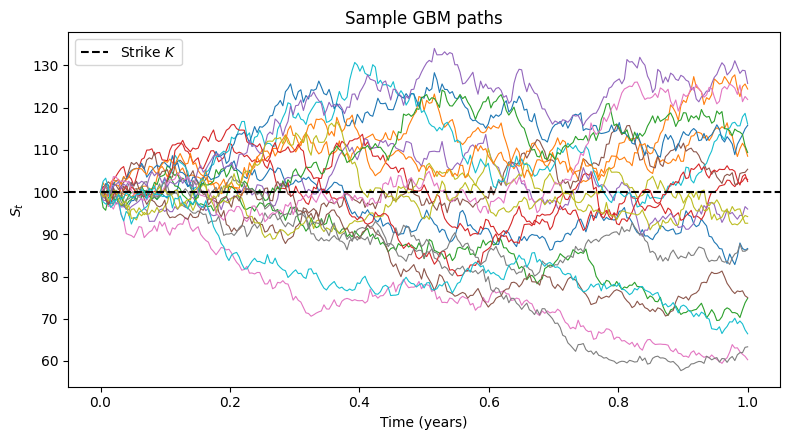

In [2]:
paths = simulate_paths(S0, r, sigma, T, n_paths=20, n_steps=252, rng=make_rng(0))

plt.figure(figsize=(8, 4.5))
plt.plot(np.linspace(0, T, paths.shape[1]), paths.T, lw=0.8)
plt.axhline(K, color="k", ls="--", label="Strike $K$")
plt.xlabel("Time (years)"); plt.ylabel("$S_t$"); plt.title("Sample GBM paths")
plt.legend(); plt.tight_layout(); plt.show()

## 3. Black-Scholes closed form (benchmark)

$$C = S_0\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2), \qquad d_1 = \frac{\ln(S_0/K) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

where $\Phi$ is the standard normal CDF. The Greeks studied below are

$$\Delta = \Phi(d_1), \qquad \text{Vega} = S_0\,\varphi(d_1)\sqrt{T}$$

where $\varphi$ is the standard normal density.

In [3]:
def bs_call(S0: float, K: float, T: float, r: float, sigma: float) -> tuple[float, float, float]:
    """Black-Scholes price, delta and vega of a European call."""
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    delta = norm.cdf(d1)
    vega = S0 * norm.pdf(d1) * np.sqrt(T)
    return price, delta, vega


bs_price, bs_delta, bs_vega = bs_call(S0, K, T, r, sigma)
print(f"BS price: {bs_price:.4f} | delta: {bs_delta:.4f} | vega: {bs_vega:.4f}")

BS price: 9.4134 | delta: 0.5987 | vega: 38.6668


## 4. Monte Carlo pricer

Only $S_T$ matters for a European payoff, so a single step is enough. The estimator is

$$\hat{C}_N = \frac{e^{-rT}}{N}\sum_{i=1}^{N} \left(S_T^{(i)} - K\right)^+$$

with standard error $\text{SE} = \hat{s}/\sqrt{N}$, where $\hat{s}$ is the sample standard deviation of the discounted payoffs. The 95% confidence interval is $\hat{C}_N \pm 1.96\,\text{SE}$.

In [4]:
def mc_call(S0: float, K: float, T: float, r: float, sigma: float,
            n: int, rng: np.random.Generator) -> tuple[float, float]:
    """Plain Monte Carlo price of a European call and its standard error."""
    ST = simulate_terminal(S0, r, sigma, T, rng.standard_normal(n))
    return mean_and_se(discounted_call_payoff(ST, K, r, T))


N = 100_000
p_mc, se_mc = mc_call(S0, K, T, r, sigma, N, make_rng(1))
print(f"MC price: {p_mc:.4f} +/- {1.96 * se_mc:.4f} (95% CI) | BS: {bs_price:.4f} "
      f"| error: {abs(p_mc - bs_price):.4f}")

MC price: 9.3626 +/- 0.0870 (95% CI) | BS: 9.4134 | error: 0.0508


With $N = 100{,}000$ simulations, the Black-Scholes price lies inside the 95% confidence interval, and the half-width of the interval is below 0.1, i.e. about 1% of the option value.

## 5. Convergence study

By the Central Limit Theorem, the error behaves like

$$\left|\hat{C}_N - C\right| = O\left(\frac{1}{\sqrt{N}}\right)$$

so it should appear as a line of slope $-1/2$ on a log-log plot. A single run per value of $N$ gives a very noisy error curve, so for each $N$ the experiment is repeated $R$ times and we report the root-mean-square error (RMSE) against the Black-Scholes price. The slope is then estimated by linear regression in log-log scale instead of being read off the plot.

Fitted slope (RMSE vs BS): -0.502 | fitted slope (SE): -0.500 | theory: -0.5


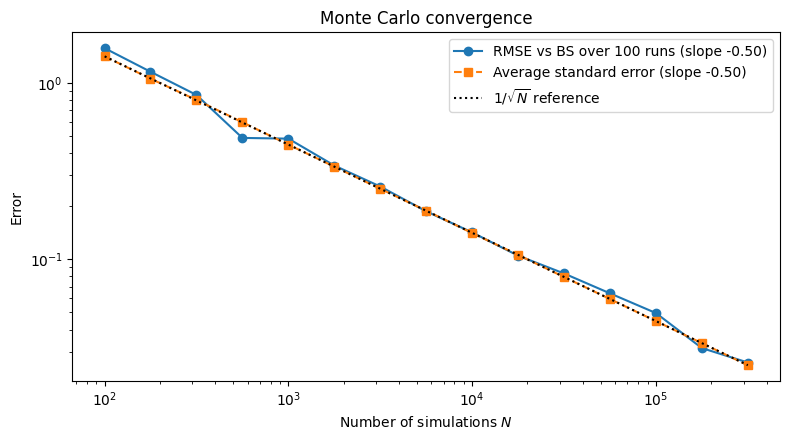

In [5]:
Ns = np.unique(np.logspace(2, 5.5, 15).astype(int))
R = 100
rng = make_rng(2)

rmse, mean_se = [], []
for n in Ns:
    runs = np.array([mc_call(S0, K, T, r, sigma, n, rng) for _ in range(R)])
    rmse.append(np.sqrt(np.mean((runs[:, 0] - bs_price) ** 2)))
    mean_se.append(runs[:, 1].mean())
rmse, mean_se = np.array(rmse), np.array(mean_se)

slope_rmse = np.polyfit(np.log(Ns), np.log(rmse), 1)[0]
slope_se = np.polyfit(np.log(Ns), np.log(mean_se), 1)[0]
print(f"Fitted slope (RMSE vs BS): {slope_rmse:.3f} | fitted slope (SE): {slope_se:.3f} | theory: -0.5")

plt.figure(figsize=(8, 4.5))
plt.loglog(Ns, rmse, "o-", label=f"RMSE vs BS over {R} runs (slope {slope_rmse:.2f})")
plt.loglog(Ns, mean_se, "s--", label=f"Average standard error (slope {slope_se:.2f})")
plt.loglog(Ns, mean_se[0] * np.sqrt(Ns[0] / Ns), "k:", label="$1/\\sqrt{N}$ reference")
plt.xlabel("Number of simulations $N$"); plt.ylabel("Error")
plt.title("Monte Carlo convergence"); plt.legend(); plt.tight_layout(); plt.show()

Both fitted slopes are close to the theoretical value of $-1/2$, and the RMSE against the true price matches the standard error estimated from the samples. This confirms that the estimator is unbiased and that the standard error is a reliable measure of the actual pricing error. In practice, dividing the error by 10 requires 100 times more simulations, which motivates the variance reduction techniques of sections 7 and 8.

## 6. Greeks by Monte Carlo (pathwise method)

The pathwise method differentiates the payoff inside the expectation. Since $\partial S_T / \partial S_0 = S_T / S_0$ and $\partial S_T / \partial \sigma = S_T\left(\sqrt{T}\,Z - \sigma T\right)$:

$$\Delta = e^{-rT}\,\mathbb{E}\left[\mathbf{1}_{\{S_T > K\}}\,\frac{S_T}{S_0}\right], \qquad \text{Vega} = e^{-rT}\,\mathbb{E}\left[\mathbf{1}_{\{S_T > K\}}\,S_T\left(\sqrt{T}\,Z - \sigma T\right)\right]$$

This is valid here because the call payoff is continuous in $S_T$. It would not work for a discontinuous payoff such as a digital option, whose derivative is zero almost everywhere; the likelihood ratio method or finite differences would be needed instead.

In [6]:
def mc_greeks(S0: float, K: float, T: float, r: float, sigma: float,
              n: int, rng: np.random.Generator) -> dict[str, tuple[float, float]]:
    """Pathwise Monte Carlo delta and vega of a European call, each with its standard error."""
    Z = rng.standard_normal(n)
    ST = simulate_terminal(S0, r, sigma, T, Z)
    itm = ST > K
    disc = np.exp(-r * T)
    return {
        "delta": mean_and_se(disc * itm * ST / S0),
        "vega": mean_and_se(disc * itm * ST * (np.sqrt(T) * Z - sigma * T)),
    }


greeks = mc_greeks(S0, K, T, r, sigma, 1_000_000, make_rng(3))
for name, bs_value in [("delta", bs_delta), ("vega", bs_vega)]:
    est, se = greeks[name]
    inside = abs(est - bs_value) <= 1.96 * se
    print(f"{name.capitalize():<6} MC: {est:.4f} +/- {1.96 * se:.4f} | BS: {bs_value:.4f} "
          f"| BS inside 95% CI: {inside}")

Delta  MC: 0.5985 +/- 0.0011 | BS: 0.5987 | BS inside 95% CI: True
Vega   MC: 38.6353 +/- 0.1469 | BS: 38.6668 | BS inside 95% CI: True


Both Greeks match their closed-form values within their 95% confidence intervals. The pathwise estimators are computed from the same simulated paths as the price, so they come almost for free.

## 7. Variance reduction: antithetic variates

Since $Z$ and $-Z$ have the same distribution, we average the discounted payoffs of each pair $(Z, -Z)$:

$$\hat{C}^{AV} = \frac{1}{N/2}\sum_{i=1}^{N/2} \frac{f(Z_i) + f(-Z_i)}{2}$$

The call payoff $f$ is increasing in $Z$, so $f(Z)$ and $f(-Z)$ are negatively correlated, which reduces the variance of each pair. To compare fairly, both estimators use the same total number $N$ of payoff evaluations.

In [7]:
def mc_call_antithetic(S0: float, K: float, T: float, r: float, sigma: float,
                       n: int, rng: np.random.Generator) -> tuple[float, float]:
    """Antithetic Monte Carlo price of a European call (n payoff evaluations in total)."""
    Z = rng.standard_normal(n // 2)
    f = lambda z: discounted_call_payoff(simulate_terminal(S0, r, sigma, T, z), K, r, T)
    return mean_and_se(0.5 * (f(Z) + f(-Z)))


p_av, se_av = mc_call_antithetic(S0, K, T, r, sigma, N, make_rng(4))
vr_av = (se_mc / se_av) ** 2
print(f"Antithetic: {p_av:.4f} +/- {1.96 * se_av:.4f} | BS: {bs_price:.4f} "
      f"| variance reduction vs plain MC: {vr_av:.1f}x")

Antithetic: 9.3787 +/- 0.0649 | BS: 9.4134 | variance reduction vs plain MC: 1.8x


The gain is real but modest. The call payoff is only "half linear" in $Z$ (it is flat below the strike), so the negative correlation within each pair is limited.

## 8. Variance reduction: control variates

The idea is to use a variable $Y$ that is highly correlated with the payoff and whose expectation is known exactly. Here $Y = e^{-rT} S_T$, whose risk-neutral expectation is $S_0$ (the discounted price is a martingale). The estimator is

$$\hat{C}^{CV} = \frac{1}{N}\sum_{i=1}^{N} \left[ X_i - \beta\left(Y_i - S_0\right) \right], \qquad \beta^* = \frac{\operatorname{Cov}(X, Y)}{\operatorname{Var}(Y)}$$

where $X$ is the discounted payoff. With the optimal $\beta^*$, the variance is reduced by a factor $1/(1 - \rho_{XY}^2)$, where $\rho_{XY}$ is the correlation between $X$ and $Y$. To avoid a small bias from estimating $\beta$ on the same samples, $\beta$ is estimated on a separate pilot run.

In [8]:
def mc_call_control_variate(S0: float, K: float, T: float, r: float, sigma: float,
                            n: int, rng: np.random.Generator,
                            n_pilot: int = 10_000) -> tuple[float, float, float]:
    """Control variate Monte Carlo price of a European call, using Y = e^{-rT} S_T as control.

    Returns the price, its standard error and the coefficient beta (estimated on a pilot run).
    """
    disc = np.exp(-r * T)

    ST_pilot = simulate_terminal(S0, r, sigma, T, rng.standard_normal(n_pilot))
    X_pilot, Y_pilot = discounted_call_payoff(ST_pilot, K, r, T), disc * ST_pilot
    beta = np.cov(X_pilot, Y_pilot)[0, 1] / Y_pilot.var(ddof=1)

    ST = simulate_terminal(S0, r, sigma, T, rng.standard_normal(n))
    X, Y = discounted_call_payoff(ST, K, r, T), disc * ST
    price, se = mean_and_se(X - beta * (Y - S0))
    return price, se, beta


p_cv, se_cv, beta = mc_call_control_variate(S0, K, T, r, sigma, N, make_rng(5))
vr_cv = (se_mc / se_cv) ** 2
print(f"Control variate: {p_cv:.4f} +/- {1.96 * se_cv:.4f} | BS: {bs_price:.4f} "
      f"| beta: {beta:.3f} | variance reduction vs plain MC: {vr_cv:.1f}x")

Control variate: 9.4087 +/- 0.0358 | BS: 9.4134 | beta: 0.637 | variance reduction vs plain MC: 5.9x


The control variate is much more effective than antithetic variates for this option, because the discounted payoff and the discounted stock price are strongly correlated.

## 9. Comparison of estimators

A variance reduction factor alone is not the whole story: a method that halves the variance but triples the computation time is not worth it. The table below therefore also reports the run time and the *efficiency gain*, defined as the variance reduction divided by the relative cost. Each estimator is run several times and the median time is kept.

In [9]:
def timed(fn, n_repeat: int = 7):
    """Run fn several times; return its last result and the median run time in seconds."""
    times, result = [], None
    for _ in range(n_repeat):
        start = time.perf_counter()
        result = fn()
        times.append(time.perf_counter() - start)
    return result, float(np.median(times))


N_BENCH = 1_000_000
methods = {
    "Plain MC": lambda: mc_call(S0, K, T, r, sigma, N_BENCH, make_rng(6)),
    "Antithetic": lambda: mc_call_antithetic(S0, K, T, r, sigma, N_BENCH, make_rng(6)),
    "Control variate": lambda: mc_call_control_variate(S0, K, T, r, sigma, N_BENCH, make_rng(6))[:2],
}

results = {name: timed(fn) for name, fn in methods.items()}
(_, se_ref), t_ref = results["Plain MC"]

print(f"N = {N_BENCH:,} payoff evaluations per estimator | BS price: {bs_price:.4f}\n")
print(f"{'Method':<16}{'Price':>9}{'95% CI +/-':>12}{'Var. red.':>11}{'Time (ms)':>11}{'Efficiency':>12}")
for name, ((price, se), t) in results.items():
    vr = (se_ref / se) ** 2
    print(f"{name:<16}{price:>9.4f}{1.96 * se:>12.4f}{vr:>10.1f}x{1000 * t:>11.1f}{vr * t_ref / t:>11.1f}x")

N = 1,000,000 payoff evaluations per estimator | BS price: 9.4134

Method              Price  95% CI +/-  Var. red.  Time (ms)  Efficiency
Plain MC           9.3987      0.0276       1.0x       23.3        1.0x
Antithetic         9.4119      0.0206       1.8x       17.5        2.4x
Control variate    9.4135      0.0113       5.9x       30.0        4.6x


The antithetic estimator is also faster than plain Monte Carlo, because it only draws $N/2$ normal variables. The control variate gives the best accuracy for a given computing budget.

## 10. Extension: arithmetic Asian call

An arithmetic Asian call pays the positive part of the average price minus the strike, with the average taken over $n$ monitoring dates $t_k = kT/n$:

$$C^{A} = e^{-rT}\,\mathbb{E}\left[\left(\frac{1}{n}\sum_{k=1}^{n} S_{t_k} - K\right)^+\right]$$

The payoff depends on the whole path, and the distribution of an arithmetic average of lognormal variables has no simple closed form. This is a typical case where Monte Carlo is the natural pricing method.

**Geometric Asian call as a control variate.** If the arithmetic average is replaced by the geometric average $G = \left(\prod_{k=1}^{n} S_{t_k}\right)^{1/n}$, then $\ln G$ is Gaussian with

$$\mu_G = \ln S_0 + \left(r - \frac{\sigma^2}{2}\right)\frac{T(n+1)}{2n}, \qquad \sigma_G^2 = \sigma^2 T\,\frac{(n+1)(2n+1)}{6n^2}$$

so the geometric Asian call has an exact price:

$$C^{G} = e^{-rT}\left[e^{\mu_G + \sigma_G^2/2}\,\Phi(d_1) - K\,\Phi(d_2)\right], \qquad d_1 = \frac{\mu_G - \ln K + \sigma_G^2}{\sigma_G}, \qquad d_2 = d_1 - \sigma_G$$

The two averages are extremely close on every path, so the geometric payoff is an excellent control variate for the arithmetic one. We first validate the Monte Carlo geometric price against its closed form, then use it to price the arithmetic option.

In [10]:
def geometric_asian_call(S0: float, K: float, T: float, r: float, sigma: float, n: int) -> float:
    """Exact price of a discretely monitored geometric Asian call (n equally spaced dates)."""
    mu_g = np.log(S0) + (r - 0.5 * sigma**2) * T * (n + 1) / (2 * n)
    sigma_g = sigma * np.sqrt(T * (n + 1) * (2 * n + 1) / (6 * n**2))
    d1 = (mu_g - np.log(K) + sigma_g**2) / sigma_g
    d2 = d1 - sigma_g
    return np.exp(-r * T) * (np.exp(mu_g + 0.5 * sigma_g**2) * norm.cdf(d1) - K * norm.cdf(d2))


def mc_asian_call(S0: float, K: float, T: float, r: float, sigma: float, n_steps: int,
                  n_paths: int, rng: np.random.Generator, batch: int = 20_000) -> dict:
    """Monte Carlo prices of arithmetic and geometric Asian calls, plus the arithmetic price
    with the geometric Asian call as control variate. Paths are simulated in batches to limit memory.
    """
    disc = np.exp(-r * T)
    X_list, Y_list = [], []
    for start in range(0, n_paths, batch):
        S = simulate_paths(S0, r, sigma, T, min(batch, n_paths - start), n_steps, rng)[:, 1:]
        X_list.append(disc * np.maximum(S.mean(axis=1) - K, 0.0))
        Y_list.append(disc * np.maximum(np.exp(np.log(S).mean(axis=1)) - K, 0.0))
    X, Y = np.concatenate(X_list), np.concatenate(Y_list)

    geo_exact = geometric_asian_call(S0, K, T, r, sigma, n_steps)
    half = n_paths // 2  # first half: estimate beta, second half: price (avoids bias)
    beta = np.cov(X[:half], Y[:half])[0, 1] / Y[:half].var(ddof=1)
    return {
        "arithmetic_plain": mean_and_se(X[half:]),
        "geometric_plain": mean_and_se(Y[half:]),
        "arithmetic_cv": mean_and_se(X[half:] - beta * (Y[half:] - geo_exact)),
        "geometric_exact": geo_exact,
        "beta": beta,
        "correlation": np.corrcoef(X, Y)[0, 1],
    }


N_STEPS, N_PATHS = 252, 200_000
asian = mc_asian_call(S0, K, T, r, sigma, N_STEPS, N_PATHS, make_rng(7))

geo_mc, geo_se = asian["geometric_plain"]
ari_mc, ari_se = asian["arithmetic_plain"]
ari_cv, ari_cv_se = asian["arithmetic_cv"]
print(f"Geometric Asian  MC: {geo_mc:.4f} +/- {1.96 * geo_se:.4f} | closed form: {asian['geometric_exact']:.4f}")
print(f"Arithmetic Asian plain MC:        {ari_mc:.4f} +/- {1.96 * ari_se:.4f}")
print(f"Arithmetic Asian control variate: {ari_cv:.4f} +/- {1.96 * ari_cv_se:.4f}")
print(f"Correlation arithmetic/geometric payoffs: {asian['correlation']:.4f} "
      f"| variance reduction: {(ari_se / ari_cv_se) ** 2:.0f}x")
print(f"For comparison, European call (BS): {bs_price:.4f}")

Geometric Asian  MC: 5.0660 +/- 0.0463 | closed form: 5.1031
Arithmetic Asian plain MC:        5.2619 +/- 0.0479
Arithmetic Asian control variate: 5.3002 +/- 0.0013
Correlation arithmetic/geometric payoffs: 0.9996 | variance reduction: 1373x
For comparison, European call (BS): 9.4134


The Monte Carlo geometric price matches its closed form, which validates the path simulation. The arithmetic and geometric payoffs are almost perfectly correlated, so the control variate shrinks the confidence interval dramatically: the same accuracy with plain Monte Carlo would require more than a thousand times more paths.

As expected, the Asian call is much cheaper than the European call: averaging the price over the year reduces the effective volatility of the underlying.

## 11. Sanity checks

A few automated checks that the notebook's results are consistent. All of them must pass.

In [11]:
def within_ci(estimate: float, se: float, target: float, z: float = 3.0) -> bool:
    """True if target lies within estimate +/- z * se (z = 3 keeps false alarms below 0.3%)."""
    return abs(estimate - target) <= z * se


# Black-Scholes: known reference value and put-call parity
bs_put = K * np.exp(-r * T) * norm.cdf(-(np.log(S0 / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))) \
         - S0 * norm.cdf(-(np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T)))
assert np.isclose(bs_price - bs_put, S0 - K * np.exp(-r * T)), "Put-call parity violated"

# Monte Carlo estimators agree with the closed forms
assert within_ci(p_mc, se_mc, bs_price), "Plain MC price"
assert within_ci(p_av, se_av, bs_price), "Antithetic price"
assert within_ci(p_cv, se_cv, bs_price), "Control variate price"
assert within_ci(*greeks["delta"], bs_delta), "MC delta"
assert within_ci(*greeks["vega"], bs_vega), "MC vega"
assert within_ci(geo_mc, geo_se, asian["geometric_exact"]), "Geometric Asian price"

# Convergence rate and variance reduction behave as expected
assert abs(slope_rmse + 0.5) < 0.1 and abs(slope_se + 0.5) < 0.05, "Convergence rate"
assert 1 < vr_av < vr_cv, "Variance reduction ordering"

# No-arbitrage bounds: Asian call cheaper than European call, both above intrinsic lower bound
assert max(S0 - K * np.exp(-r * T), 0) <= bs_price <= S0, "European call bounds"
assert ari_cv < bs_price, "Asian call should be cheaper than the European call"

print("All sanity checks passed.")

All sanity checks passed.


## 12. Conclusions

- **Validation.** Plain Monte Carlo, antithetic and control variate estimators all recover the Black-Scholes price within their confidence intervals, and the pathwise Greeks match the closed-form delta and vega.
- **Convergence.** The fitted log-log slope of the error is $-0.50$, exactly the $O(1/\sqrt{N})$ rate predicted by the Central Limit Theorem, and the sample standard error correctly measures the true pricing error.
- **Variance reduction.** For the European call, antithetic variates reduce the variance by about 1.8x and control variates (discounted stock price) by about 6x. Accounting for run time, the control variate is the most efficient estimator.
- **Path-dependent options.** For the arithmetic Asian call, which has no simple closed form, using the geometric Asian call as a control variate reduces the variance by more than 1,000x, because the two payoffs are almost perfectly correlated.
- **Takeaway.** The choice of variance reduction technique matters far more than raw simulation count: a well-chosen control variate is worth orders of magnitude more simulations.